In [2]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pulp import (
    GUROBI_CMD, LpBinary, LpMaximize, LpMinimize, LpProblem, 
    LpStatus, LpVariable, lpSum
)
import scipy as sc
from sklearn.metrics import r2_score
from src.custom_fastkan import FastKAN, FastKANLayer
import src.kan_verification_grapher as kan_verification_grapher
import ssl
import time
from torch import autograd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
from typing import List, Dict, Any, Tuple, Optional, Union

In [3]:
def train_mnist():
    ssl._create_default_https_context = ssl._create_unverified_context
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    )
    trainset = torchvision.datasets.MNIST(
        root="./data_mnist", train=True, download=True, transform=transform
    )
    valset = torchvision.datasets.MNIST(
        root="./data_mnist", train=False, download=True, transform=transform
    )
    trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
    valloader = DataLoader(valset, batch_size=64, shuffle=False)

    model = FastKAN([28 * 28, 3, 3, 10], use_base_update=False, use_layernorm=False)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.8)

    criterion = nn.CrossEntropyLoss()
    for epoch in range(2):
        model.train()
        with tqdm(trainloader) as pbar:
            for i, (images, labels) in enumerate(pbar):
                images = images.view(-1, 28 * 28).to(device)
                optimizer.zero_grad()
                output = model(images)
                loss = criterion(output, labels.to(device))
                l2_reg = sum(torch.norm(param, p=2) for param in model.parameters())
                loss = loss + 0.01 * l2_reg
                loss.backward()
                optimizer.step()
                accuracy = (output.argmax(dim=1) == labels.to(device)).float().mean()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        model.eval()
        val_loss = 0
        val_accuracy = 0
        with torch.no_grad():
            for images, labels in valloader:
                images = images.view(-1, 28 * 28).to(device)
                output = model(images)
                val_loss += criterion(output, labels.to(device)).item()
                val_accuracy += (
                    (output.argmax(dim=1) == labels.to(device)).float().mean().item()
                )
        val_loss /= len(valloader)
        val_accuracy /= len(valloader)
        scheduler.step()

        print(
            f"Epoch {epoch + 1}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}"
        )
    return model

kan_mnist = FastKAN([4, 4, 2, 1], num_grids=8, use_base_update=False, use_layernorm=False)#train_mnist()

In [4]:
def fit_line_through_points(x1, y1, x2, y2):
    slope = (y2 - y1) / (x2 - x1)
    intercept = y1 - slope * x1
    return slope, intercept

def find_bspline_segments_given_max_segments(layer, input_index, output_index, max_segments):
    n_samples = 25
   # x_points = np.linspace(min_x, max_x, n_samples)
    x_tensor, y_tensor = layer.plot_curve(input_index, output_index, num_pts=n_samples) # return 25 equidistant pts for x_tensor, 25 varying heights for y_tensor
    x_points, y_points = x_tensor.detach().cpu().numpy(), y_tensor.detach().cpu().numpy()
    
    # Precompute errors for all possible segments
    errors = np.full((n_samples, n_samples), np.inf)
    for start_idx in range(n_samples-1):
        x_start = x_points[start_idx]
        y_start = y_points[start_idx]
        for end_idx in range(start_idx + 1, n_samples):
            x_end = x_points[end_idx]
            y_end = y_points[end_idx]
            slope, intercept = fit_line_through_points(x_start, y_start, x_end, y_end)
            segment_x = x_points[start_idx:end_idx+1]
            segment_y = y_points[start_idx:end_idx+1]
            predicted_y = slope * segment_x + intercept
            segment_error = np.max(np.abs(predicted_y - segment_y))
            errors[start_idx, end_idx] = segment_error
    
    # Dynamic programming to find optimal segmentation
    dp_table = np.full((max_segments, n_samples), np.inf) #[8, 25]
    backtrack = np.zeros((max_segments, n_samples), dtype=int)
    for j in range(1, n_samples):  # Base Case: fill in first row of dp table (using just 1 segment to fit curve)
        dp_table[0, j] = errors[0, j]
    
    # TODO: add in recurrence relation
    for i in range(1, max_segments):
        for j in range(i+1, n_samples):
            for k in range(i, j):
                if dp_table[i-1, k] == np.inf:
                    continue
                if errors[k, j] == np.inf:
                    continue
                curr_error = max(dp_table[i-1, k], errors[k, j])
                if curr_error < dp_table[i, j]:
                    dp_table[i, j] = curr_error
                    backtrack[i, j] = k
    
    # Reconstruct the segments
    segments = []
    curr_seg = n_samples - 1
    if dp_table[max_segments-1, curr_seg] == np.inf:
        return [], np.inf
    for i in range(max_segments-1, -1, -1):
        if i > 0:
            prev_seg = backtrack[i, curr_seg]
        else:
            prev_seg = 0
        x1, y1 = x_points[prev_seg], y_points[prev_seg]
        x2, y2 = x_points[curr_seg], y_points[curr_seg]
        slope, intercept = fit_line_through_points(x1, y1, x2, y2)
        segments.insert(0, (x1, x2, slope, intercept))
        curr_seg = prev_seg
        if curr_seg <= 0:
            break
        
    return segments, dp_table[max_segments-1, n_samples-1]

def fit_kan_vanilla(kan_model, segments_per_curve):
    all_segments = []
    for layer_idx, layer in enumerate(kan_model.layers):
        layer.cpu()
        input_dim = layer.input_dim
        output_dim = layer.output_dim
        print(f"Fitting Layer {layer_idx} ({input_dim} -> {output_dim})")
        for input_index in range(input_dim):
            for output_index in range(output_dim):
                segments, max_error = find_bspline_segments_given_max_segments(layer, input_index, output_index, segments_per_curve)
                all_segments.append({
                    'layer_idx': layer_idx,
                    'input_idx': input_index,
                    'output_idx': output_index,
                    'segments': segments,
                    'max_error': max_error
                })
    print(f"Generated data for {len(all_segments)} connections.")
    return all_segments


all_segments = fit_kan_vanilla(
    kan_mnist,
    segments_per_curve=8
)

Fitting Layer 0 (4 -> 4)
Fitting Layer 1 (4 -> 2)
Fitting Layer 2 (2 -> 1)
Generated data for 26 connections.


Analyzing Layer 0: 4 inputs -> 4 outputs
Analyzing Layer 1: 4 inputs -> 2 outputs
Analyzing Layer 2: 2 inputs -> 1 outputs


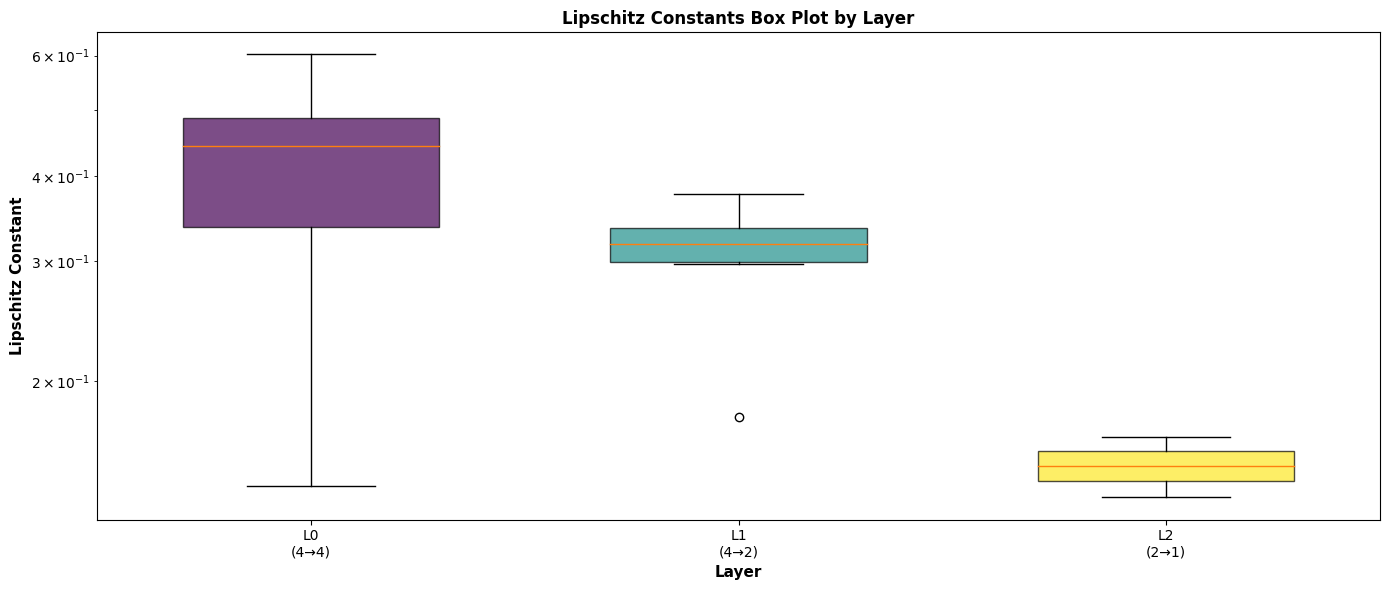

In [5]:
def calculate_bspline_lipschitz_constant(layer: 'FastKANLayer', input_idx: int, output_idx: int, num_pts: int = 1000, min_x: float = None, max_x: float = None) -> float:
    if min_x is None:
        min_x = layer.rbf.grid_min
    if max_x is None:
        max_x = layer.rbf.grid_max
    x_tensor, y_tensor = layer.plot_curve(input_idx, output_idx, num_pts=num_pts)
    x_np = x_tensor.detach().cpu().numpy()
    y_np = y_tensor.detach().cpu().numpy()
    mask = (x_np >= min_x) & (x_np <= max_x)
    x_np = x_np[mask]
    y_np = y_np[mask]

    dx = np.diff(x_np)
    dy = np.diff(y_np)
    nonzero_dx = dx != 0
    slopes = np.zeros_like(dx)
    slopes[nonzero_dx] = dy[nonzero_dx] / dx[nonzero_dx]
    lipschitz_constant = np.max(np.abs(slopes))
    return lipschitz_constant

def compute_dp_tables_lipschitz(kan_model, max_segments=15):
    error_tables = {}
    segments_tables = {}
    lipschitz_constants = {}
    
    # Iterate through all layers
    for layer_idx, layer in enumerate(kan_model.layers):
        input_dim = layer.input_dim
        output_dim = layer.output_dim
        print(f"Analyzing Layer {layer_idx}: {input_dim} inputs -> {output_dim} outputs")
        # Iterate through all B-splines in this layer
        for input_idx in range(input_dim):
            for output_idx in range(output_dim):
                spline_key = (layer_idx, input_idx, output_idx)
                layer = kan_model.layers[layer_idx]
                error_table = {}
                segments_table = {}
                for num_segments in range(1, max_segments + 1):
                    segments, error = find_bspline_segments_given_max_segments(layer, input_idx, output_idx, num_segments)
                    error_table[num_segments] = error
                    segments_table[num_segments] = segments
                lipschitz_constant = calculate_bspline_lipschitz_constant(layer=layer, input_idx=input_idx, output_idx=output_idx)
                error_tables[spline_key] = error_table
                segments_tables[spline_key] = segments_table
                lipschitz_constants[spline_key] = lipschitz_constant
    
    return error_tables, segments_tables, lipschitz_constants


error_tables, segments_tables, lipschitz_constants = compute_dp_tables_lipschitz(kan_mnist, 30)

def plot_lipschitz_comparison_by_layer(lipschitz_constants, kan_model, figsize=(14, 6)):
    """
    Create a comparative visualization showing Lipschitz constants across layers.
    
    Parameters:
    -----------
    lipschitz_constants : dict
        Dictionary mapping spline_key -> lipschitz_constant
    kan_model : FastKAN
        The KAN model being analyzed
    figsize : tuple
        Figure size
    """
    num_layers = len(kan_model.layers)
    
    # Organize data by layer
    layer_data = {i: [] for i in range(num_layers)}
    
    for (layer_idx, input_idx, output_idx), lip_const in lipschitz_constants.items():
        if np.isfinite(lip_const):
            layer_data[layer_idx].append(lip_const)
    
    fig, ax2 = plt.subplots(1, 1, figsize=figsize)
    
    # Violin plot
    positions = []
    data_to_plot = []
    labels = []
    
    for layer_idx in range(num_layers):
        if layer_data[layer_idx]:
            positions.append(layer_idx)
            data_to_plot.append(layer_data[layer_idx])
            layer = kan_model.layers[layer_idx]
            labels.append(f'L{layer_idx}\n({layer.input_dim}→{layer.output_dim})')


    
    # Comparative box plot with log scale
    bp = ax2.boxplot(data_to_plot, positions=positions, patch_artist=True,
                     labels=labels, widths=0.6)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(data_to_plot)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax2.set_xlabel('Layer', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Lipschitz Constant', fontsize=11, fontweight='bold')
    ax2.set_title('Lipschitz Constants Box Plot by Layer', fontsize=12, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig

fig2 = plot_lipschitz_comparison_by_layer(lipschitz_constants, kan_mnist)
plt.show()

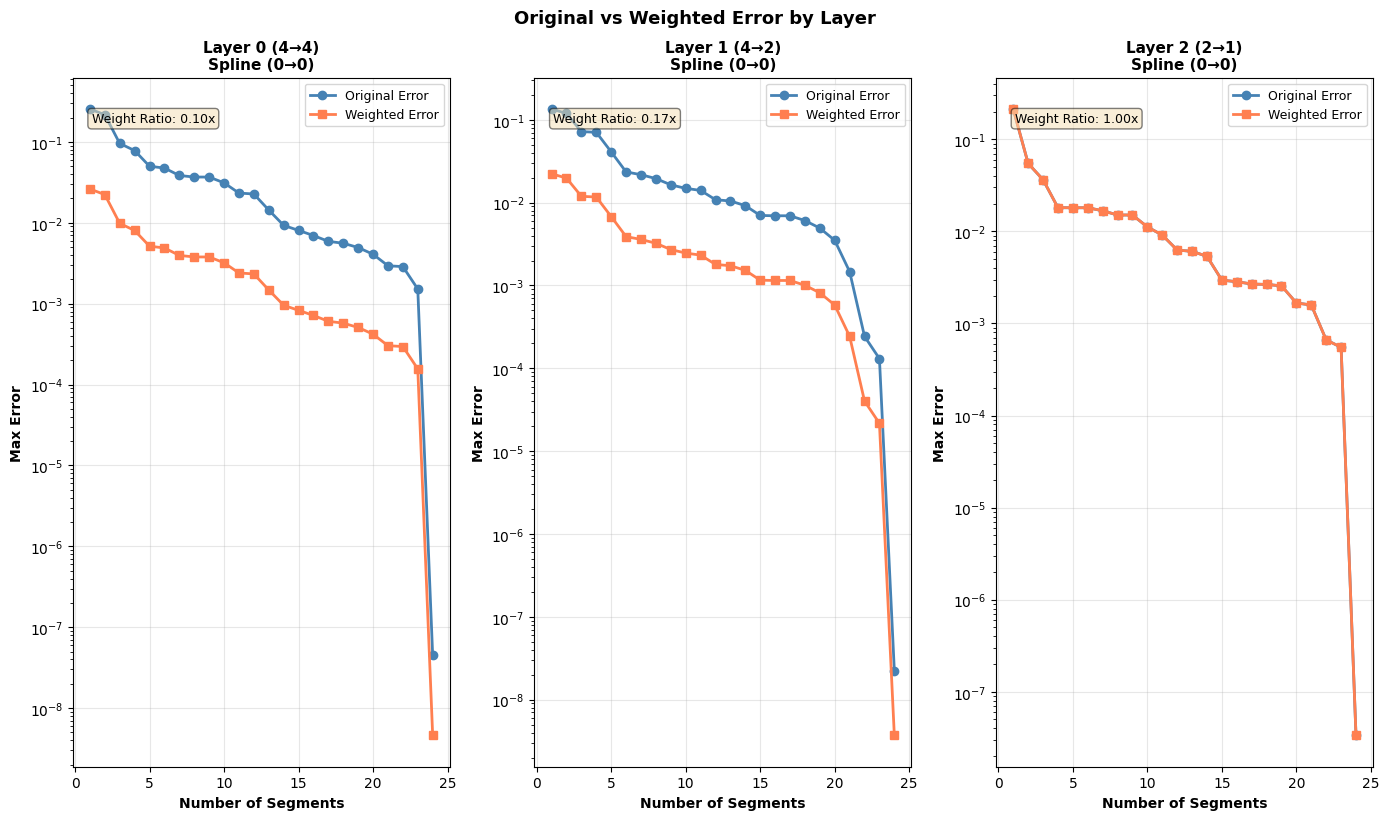

In [6]:
def weight_dp_tables_lipschitz(kan_model, error_tables, segments_tables, lipschitz_constants):
    node_sensitivities = {}
    num_layers = len(kan_model.layers)
    
    # Intialize final layer with all 1's
    final_layer = kan_model.layers[num_layers - 1]
    for out_idx in range(final_layer.output_dim):
        node_sensitivities[(num_layers, out_idx)] = 1.0

    # Calculate sensitivity for the inputs of a layer based on the output layer's sensitivities
    layer_idx = num_layers - 1
    while layer_idx >= 0:
        current_layer = kan_model.layers[layer_idx]
        for input_idx in range(current_layer.input_dim):
            sensitivity_sum = 0.0
            for output_idx in range(current_layer.output_dim):
                lipschitz_constant = lipschitz_constants.get((layer_idx, input_idx, output_idx), 0.0)
                child_node_sensitivity = node_sensitivities[(layer_idx + 1, output_idx)]
                sensitivity_sum += lipschitz_constant * child_node_sensitivity
            node_sensitivities[(layer_idx, input_idx)] = sensitivity_sum
        layer_idx -= 1

    # Weight the error table (just do sensitivities * table)
    weighted_error_tables = {}
    for layer_idx, layer in enumerate(kan_model.layers):
        for input_idx in range(layer.input_dim):
            for output_idx in range(layer.output_dim):
                current_bspline_key = (layer_idx, input_idx, output_idx)
                # The error of a spline is added directly to its destination node (output_idx)
                sensitivity_of_current_output_node = node_sensitivities[(layer_idx + 1, output_idx)]
                weighted_table_for_bspline = {}
                for pair in error_tables[current_bspline_key].items():
                    num_segments = pair[0]
                    error = pair[1]
                    weighted_table_for_bspline[num_segments] = error * sensitivity_of_current_output_node
                weighted_error_tables[current_bspline_key] = weighted_table_for_bspline
    return weighted_error_tables

weighted_error_tables = weight_dp_tables_lipschitz(kan_mnist, error_tables, segments_tables, lipschitz_constants)

import matplotlib.pyplot as plt
import numpy as np

def plot_error_comparison_by_layer(error_tables, weighted_error_tables, kan_model, 
                                   max_segments=15, figsize=(14, 8)):
    num_layers = len(kan_model.layers)
    
    # Select one representative spline from each layer (e.g., first spline)
    sample_splines = []
    for layer_idx in range(num_layers):
        layer = kan_model.layers[layer_idx]
        # Pick the first available spline (input_idx=0, output_idx=0)
        spline_key = (layer_idx, 0, 0)
        if spline_key in error_tables and spline_key in weighted_error_tables:
            sample_splines.append(spline_key)
        else:
            print(f"Warning: Spline {spline_key} not found in tables")
    
    if not sample_splines:
        print("No valid splines found to plot")
        return None
    
    # Create subplots: one for each layer
    fig, axes = plt.subplots(1, len(sample_splines), figsize=figsize, squeeze=False)
    axes = axes.flatten()
    
    for idx, spline_key in enumerate(sample_splines):
        layer_idx, input_idx, output_idx = spline_key
        layer = kan_model.layers[layer_idx]
        
        # Extract errors
        original_errors = error_tables[spline_key]
        weighted_errors = weighted_error_tables[spline_key]
        
        # Prepare data for plotting
        num_segments_list = sorted([k for k in original_errors.keys() if k <= max_segments])
        original_vals = [original_errors[k] for k in num_segments_list if np.isfinite(original_errors[k])]
        weighted_vals = [weighted_errors[k] for k in num_segments_list if np.isfinite(weighted_errors[k])]
        
        # Truncate if needed
        min_len = min(len(num_segments_list), len(original_vals), len(weighted_vals))
        num_segments_list = num_segments_list[:min_len]
        original_vals = original_vals[:min_len]
        weighted_vals = weighted_vals[:min_len]
        
        ax = axes[idx]
        
        # Plot both error curves
        ax.plot(num_segments_list, original_vals, 'o-', label='Original Error', 
                color='steelblue', linewidth=2, markersize=6)
        ax.plot(num_segments_list, weighted_vals, 's-', label='Weighted Error', 
                color='coral', linewidth=2, markersize=6)
        
        # Styling
        ax.set_xlabel('Number of Segments', fontsize=10, fontweight='bold')
        ax.set_ylabel('Max Error', fontsize=10, fontweight='bold')
        ax.set_title(f'Layer {layer_idx} ({layer.input_dim}→{layer.output_dim})\n'
                    f'Spline ({input_idx}→{output_idx})', 
                    fontsize=11, fontweight='bold')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
        
        # Add annotation for the ratio at max segments
        if original_vals and weighted_vals and original_vals[-1] > 0:
            ratio = weighted_vals[-1] / original_vals[-1]
            ax.text(0.05, 0.95, f'Weight Ratio: {ratio:.2f}x', 
                   transform=ax.transAxes, fontsize=9,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    fig.suptitle('Original vs Weighted Error by Layer', 
                fontsize=13, fontweight='bold', y=1.02)
    
    return fig


# Usage example (add after computing weighted_error_tables):
fig = plot_error_comparison_by_layer(error_tables, weighted_error_tables, kan_mnist, max_segments=30)
plt.show()

In [7]:
def fit_kan_optimally_lipschitz(weighted_error_tables, segments_tables, max_error, max_segments):
    all_splines = list(weighted_error_tables.keys())
    num_splines = len(all_splines)
    max_total_segments = num_splines * max_segments
    
    # Initialization: dp[i][j] = minimum error achievable when allocating j total segments to the first i splines
    dp = np.full((num_splines + 1, max_total_segments + 1), float('inf'))
    dp[0, 0] = 0  # Base case: 0 error when allocating 0 segments to 0 splines
    backtrack = np.zeros((num_splines + 1, max_total_segments + 1), dtype=int)
    for i in range(1, num_splines + 1):
        spline_key = all_splines[i-1]
        for j in range(max_total_segments + 1):
            # Try different allocations for the current spline (updating allocation if we find a better error)
            for segs in range(min(j + 1, max_segments + 1)):
                if segs not in weighted_error_tables[spline_key]:
                    continue
                spline_error = weighted_error_tables[spline_key][segs]
                prev_error = dp[i-1, j-segs]
                if prev_error != float('inf') and max(prev_error, spline_error) < dp[i, j]:
                    dp[i, j] = max(prev_error, spline_error)
                    backtrack[i, j] = segs
    
    # Backtrack: Find the min total segments to achieve error <= max_error
    optimal_total_segments = None
    achieved_error = float('inf')
    for j in range(max_total_segments + 1):
        if dp[num_splines, j] <= max_error:
            optimal_total_segments = j
            achieved_error = dp[num_splines, j]
            break
    if optimal_total_segments is None:
        raise ValueError("No feasible allocation found within the max error constraint.")
    optimal_allocation = {}
    actual_segments = {}
    remaining_segments = optimal_total_segments
    for i in range(num_splines, 0, -1):
        spline_key = all_splines[i-1]
        # Get the segment allocation for this spline and store the coordinates of its linear segments
        segs_for_spline = int(backtrack[i, remaining_segments])
        optimal_allocation[spline_key] = segs_for_spline
        actual_segments[spline_key] = segments_tables[spline_key].get(segs_for_spline, [])
        remaining_segments -= segs_for_spline
    total_segments = sum(optimal_allocation.values())
    print(f"  Achieved error: {achieved_error}")
    print(f"  Total segments allocated: {total_segments}")

    return optimal_allocation, actual_segments, total_segments, achieved_error, dp


optimal_allocation, actual_segments, total_segments, achieved_error, dp_table = fit_kan_optimally_lipschitz(
    weighted_error_tables, 
    segments_tables,
    0.1,
    50
)
kan_verification_grapher.print_dp_table(dp_table, len(optimal_allocation), total_segments)
#figures = kan_verification_grapher.visualize_all_splines(kan_duffing, optimal_allocation, actual_segments)

  Achieved error: 0.0547381192445755
  Total segments allocated: 27

Dynamic Programming Table (Error values):
--------------------------------------------------------------------------------
Spline \ Segments |     0 |    20
---------------------------------
  0 | 0.000 | inf  
  1 | inf   | 0.000
  2 | inf   | 0.001
  3 | inf   | 0.004
  4 | inf   | 0.005
  5 | inf   | 0.006
  6 | inf   | 0.009
  7 | inf   | 0.010
  8 | inf   | 0.012
  9 | inf   | 0.016
 10 | inf   | 0.018
 11 | inf   | 0.019
 12 | inf   | 0.020
 13 | inf   | 0.022
 14 | inf   | 0.022
 15 | inf   | 0.023
 16 | inf   | 0.023
 17 | inf   | 0.024
 18 | inf   | 0.026
 19 | inf   | 0.029
 20 | inf   | 0.046
 21 | inf   | inf  
 22 | inf   | inf  
 23 | inf   | inf  
 24 | inf   | inf  
 25 | inf   | inf  
 26 | inf   | inf  
--------------------------------------------------------------------------------
Note: 'inf' indicates that the error is infinite (impossible allocation)
Only the first 100 columns are shown (if appli

In [8]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

def solve_kan_interval_milp(segments_tables, optimal_config, x_min_vec, x_max_vec):
    """
    Performs exact interval analysis on a KAN model using MILP.
    Calculates the tightest possible output bounds given input bounds.

    Args:
        segments_tables (dict): 
            The precomputed dictionary of all possible segment fits.
            Key: (layer_idx, input_idx, output_idx)
            Value: dict {num_segments: [(x1, x2, slope, intercept), ...]}
        optimal_config (dict):
            The specific number of segments chosen for each connection.
            Key: (layer_idx, input_idx, output_idx)
            Value: selected_num_segments (int)
        x_min_vec (list or np.array): Lower bounds for input features.
        x_max_vec (list or np.array): Upper bounds for input features.

    Returns:
        tuple: (min_output_vec, max_output_vec) as numpy arrays.
    """
    
    # Identify model dimensions from the config keys
    layers = sorted(list(set([k[0] for k in optimal_config.keys()])))
    num_layers = max(layers) + 1
    
    # Determine input/output dimensions for each layer
    # We scan the keys to find the max index for inputs and outputs per layer
    layer_dims = {}
    for (l, i, o) in optimal_config.keys():
        if l not in layer_dims:
            layer_dims[l] = {'in': 0, 'out': 0}
        layer_dims[l]['in'] = max(layer_dims[l]['in'], i + 1)
        layer_dims[l]['out'] = max(layer_dims[l]['out'], o + 1)

    # Initialize Model
    model = gp.Model("KAN_Interval_Analysis")
    
    # Dictionary to store node variables: vars[layer_idx][neuron_idx]
    node_vars = {}

    # ---------------------------------------------------------
    # 1. Setup Input Layer (Layer 0 Inputs)
    # ---------------------------------------------------------
    input_dim = layer_dims[0]['in']
    if len(x_min_vec) != input_dim or len(x_max_vec) != input_dim:
        raise ValueError(f"Input bounds dimension {len(x_min_vec)} does not match Model Input {input_dim}")

    node_vars[0] = []
    for i in range(input_dim):
        # Create variable for input node with hard bounds
        var = model.addVar(
            lb=x_min_vec[i], 
            ub=x_max_vec[i], 
            name=f"node_0_{i}"
        )
        node_vars[0].append(var)

    # ---------------------------------------------------------
    # 2. Build Network Constraints
    # ---------------------------------------------------------
    for l in range(num_layers):
        # -----------------------------------------------------
        # PREPARATION: Destination Buckets (Layer l -> Layer l+1)
        # -----------------------------------------------------
        # We are calculating the edges that leave Layer 'l' and arrive at Layer 'l+1'.
        # We need a place to collect all these signals before summing them up.
        
        num_neurons_in_next_layer = layer_dims[l]['out']
        
        # 'signals_arriving_at_next_layer_neuron' is a dictionary of lists.
        # KEY (j): The index of a specific neuron in the NEXT layer (l+1).
        # VALUE: A list of Gurobi variables (phi) that represent the outputs of splines 
        #        pointing specifically to that neuron.
        signals_arriving_at_next_layer_neuron = {j: [] for j in range(num_neurons_in_next_layer)}
        
        # A. Process BSplines (The Edges)
        # We iterate through the config to find all splines in this current layer 'l'
        layer_splines = [key for key in optimal_config.keys() if key[0] == l]
        
        for (l_idx, i, j) in layer_splines:
            # i = source neuron index (in current layer l)
            # j = destination neuron index (in next layer l+1)
            
            # Get the input variable corresponding to this spline's source
            input_var = node_vars[l][i]
            
            # Retrieve segment data
            num_segs = optimal_config[(l, i, j)]
            seg_data = segments_tables[(l, i, j)][num_segs]
            
            # Prepare Points for PWL Constraint
            x_pts = []
            y_pts = []
            
            for idx, (x1, x2, slope, intercept) in enumerate(seg_data):
                y1 = slope * x1 + intercept
                x_pts.append(x1)
                y_pts.append(y1)
                
                if idx == len(seg_data) - 1:
                    y2 = slope * x2 + intercept
                    x_pts.append(x2)
                    y_pts.append(y2)
            
            # Create Intermediate Variable (Output of the Spline)
            # phi_{l}_{i}_{j} represents the activation function output
            phi_var = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY, name=f"phi_{l}_{i}_{j}")
            
            # Add the Piecewise Linear Constraint
            model.addGenConstrPWL(input_var, phi_var, x_pts, y_pts, name=f"pwl_{l}_{i}_{j}")
            
            # Register this contribution to the specific DESTINATION node j
            signals_arriving_at_next_layer_neuron[j].append(phi_var)

        # B. Process Nodes (Summation at Destination)
        # Create variables for the neurons in the next layer (l+1)
        node_vars[l+1] = []
        
        for j in range(num_neurons_in_next_layer):
            # Create the node variable for Neuron j in Layer l+1
            destination_node_var = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY, name=f"node_{l+1}_{j}")
            node_vars[l+1].append(destination_node_var)
            
            # Summation Constraint: 
            # The value of Destination Neuron j = Sum of all signals arriving at j
            model.addConstr(
                destination_node_var == gp.quicksum(signals_arriving_at_next_layer_neuron[j]), 
                name=f"sum_{l+1}_{j}"
            )

    model.update()
    
    # ---------------------------------------------------------
    # 3. Solve for Min and Max of Output Layer
    # ---------------------------------------------------------
    final_layer_idx = num_layers
    final_vars = node_vars[final_layer_idx]
    
    min_outputs = []
    max_outputs = []
    
    print(f"Calculating intervals for {len(final_vars)} output neurons...")
    
    for idx, out_var in enumerate(final_vars):
        # --- Minimize ---
        model.setObjective(out_var, GRB.MINIMIZE)
        model.optimize()
        
        if model.status == GRB.OPTIMAL:
            min_outputs.append(model.objVal)
        else:
            print(f"Warning: Minimization failed for output {idx} (Status {model.status})")
            min_outputs.append(np.nan)
            
        # --- Maximize ---
        model.setObjective(out_var, GRB.MAXIMIZE)
        model.optimize()
        
        if model.status == GRB.OPTIMAL:
            max_outputs.append(model.objVal)
        else:
            print(f"Warning: Maximization failed for output {idx} (Status {model.status})")
            max_outputs.append(np.nan)
            
    return np.array(min_outputs), np.array(max_outputs)


input_dim = max(k[1] for k in optimal_allocation.keys() if k[0] == 0) + 1

# Example: Define bounds for each input feature
x_min_vec = np.full(input_dim, -4.0)  # Lower bounds (adjust as needed)
x_max_vec = np.full(input_dim, 4.0)   # Upper bounds (adjust as needed)

# Run interval analysis
min_outputs, max_outputs = solve_kan_interval_milp(
    segments_tables, 
    optimal_allocation,  # This is the optimal_config from solve_best_segment_allocation
    x_min_vec, 
    x_max_vec
)

print("Minimum Output Bounds:", min_outputs)
print("Maximum Output Bounds:", max_outputs)

Set parameter Username
Set parameter LicenseID to value 2620375
Academic license - for non-commercial use only - expires 2026-02-10
Calculating intervals for 1 output neurons...
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M2 Pro
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 7 rows, 37 columns and 33 nonzeros
Model fingerprint: 0xd9612a83
Model has 26 simple general constraints
  26 PWL
Variable types: 37 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [4e+00, 4e+00]
  RHS range        [0e+00, 0e+00]
  PWLCon x range   [2e+00, 2e+00]
  PWLCon y range   [2e-01, 2e-01]
Presolve removed 7 rows and 37 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 1 (of 10 available process